In [92]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import holidays

In [87]:
data = pd.read_excel("/Users/neilsinclair/Documents/Freelance/energy/data/energy_profile.xlsx", header=2)
data.drop(columns=["Unnamed: 0"], inplace=True)

months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
data_types = ["SA", "FT", "WT"]
new_months = []
for month in months:
  for data_type in data_types:
    new_months.append(month+"_"+data_type)

data.columns = ["Time"] + new_months
data.drop(index=0, inplace=True)
data.dropna(axis=0,subset=["Time"], inplace=True)

data = data.melt(id_vars="Time")

data.columns = ["Time Period", "Date", "Value"]
data["month_name"] = data.Date.apply(lambda x: x.split("_")[0])
data["day_type"] = data.Date.apply(lambda x: x.split("_")[1])
data["time"] = data["Time Period"].apply(lambda x: x.split("-")[0])
data["time"] = pd.to_datetime(data["time"], format="%H:%M").dt.time

data.drop(columns=["Date", "Time Period"], inplace=True)


In [88]:
data

,Value,month_name,day_type,time
0,15.045,January,SA,00:00:00
1,14.908,January,SA,00:15:00
2,14.785,January,SA,00:30:00
3,14.739,January,SA,00:45:00
4,14.674,January,SA,01:00:00
...,...,...,...,...
3451,17.1,December,WT,22:45:00
3452,16.686,December,WT,23:00:00
3453,16.318,December,WT,23:15:00
3454,16.126,December,WT,23:30:00


In [93]:
day_map = {
  "Monday": "WT",
  "Tuesday": "WT",
  "Wednesday": "WT",
  "Thursday": "WT",
  "Friday": "WT",
  "Saturday": "ST",
  "Sunday": "FT"
}

de_holidays = holidays.Germany(years=2025)

# 1. Create all 15-minute timestamps for 2025
dt_index = pd.date_range(
    start="2025-01-01 00:00",
    end="2025-12-31 23:45",   # last 15-minute slot of the year
    freq="15min"
)

df = pd.DataFrame({"datetime": dt_index})

# 2. Add date, time, weekday name
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["weekday"] = df["datetime"].dt.day_name() 
df["month_name"] = df["datetime"].dt.month_name()
# df["weekday"] = df["datetime"].dt.day_name(locale="de_DE")  # if you have locale set up
# Name of holiday (or None)
df["holiday_name"] = df["datetime"].dt.date.map(de_holidays.get)

# Boolean flag for “is public holiday?”
df["is_holiday"] = df["holiday_name"].notna()
df["day_type"] = df["weekday"].map(day_map)
df.loc[df["is_holiday"], "day_type"] = "FT"

pd.set_option("display.max_rows", 10)

df = df.merge(
  data,
  on = ["month_name", "day_type", "time"],
  how="left"
)

df.head(100)

,datetime,date,time,weekday,month_name,holiday_name,is_holiday,day_type,Value
0,2025-01-01 00:00:00,2025-01-01,00:00:00,Wednesday,January,Neujahr,True,FT,14.658
1,2025-01-01 00:15:00,2025-01-01,00:15:00,Wednesday,January,Neujahr,True,FT,14.602
2,2025-01-01 00:30:00,2025-01-01,00:30:00,Wednesday,January,Neujahr,True,FT,14.43
3,2025-01-01 00:45:00,2025-01-01,00:45:00,Wednesday,January,Neujahr,True,FT,14.244
4,2025-01-01 01:00:00,2025-01-01,01:00:00,Wednesday,January,Neujahr,True,FT,14.226
...,...,...,...,...,...,...,...,...,...
95,2025-01-01 23:45:00,2025-01-01,23:45:00,Wednesday,January,Neujahr,True,FT,14.117
96,2025-01-02 00:00:00,2025-01-02,00:00:00,Thursday,January,None,False,WT,14.832
97,2025-01-02 00:15:00,2025-01-02,00:15:00,Thursday,January,None,False,WT,14.721
98,2025-01-02 00:30:00,2025-01-02,00:30:00,Thursday,January,None,False,WT,14.618


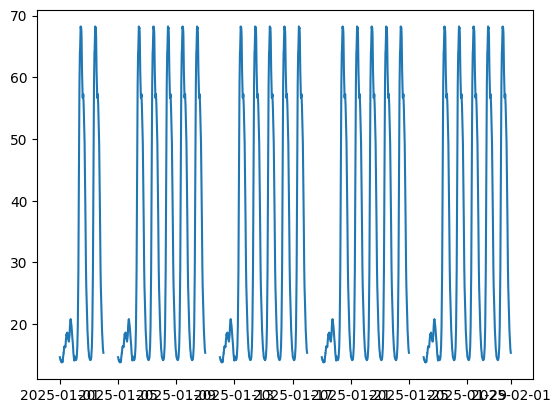

In [96]:
plt.plot(df[df.month_name=="January"]["datetime"], df[df.month_name=="January"]["Value"])